In [1]:
import pandas as pd

df = pd.read_csv("jobstreet_all_job_dataset.csv", engine='python', on_bad_lines='skip')
df.head()

,job_id,job_title,company,descriptions,location,category,subcategory,role,type,salary,listingDate
0,74630583,Procurement Executive (Contract),Coca-Cola Bottlers (Malaysia) Sdn Bhd,Position Purpose\nManage aspects of procuremen...,Negeri Sembilan,"Manufacturing, Transport & Logistics","Purchasing, Procurement & Inventory",procurement-executive,Contract/Temp,NaN,2024-03-21T05:58:35Z
1,74660602,Account Executive/ Assistant,Acoustic & Lighting System Sdn Bhd,We are looking for a Account Executive/ Assist...,Petaling,Accounting,Bookkeeping & Small Practice Accounting,executive-assistant,Full time,"RM 2,800 – RM 3,200 per month",2024-03-22T06:52:57Z
2,74655679,"Data Analyst - Asset Management, SPX Express",Shopee Mobile Malaysia Sdn Bhd,Performs detailed data analysis on existing sp...,Klang District,"Manufacturing, Transport & Logistics",Analysis & Reporting,asset-management-analyst,Full time,NaN,2024-03-22T04:22:43Z
3,74657624,Service Engineer,Sun Medical Systems Sdn Bhd,"You are important for troubleshooting, install...",Petaling,Engineering,Electrical/Electronic Engineering,services-engineer,Full time,"RM 3,000 – RM 3,500 per month",2024-03-22T05:32:09Z
4,74679363,Purchasing Executive,Magnet Security & Automation Sdn. Bhd.,"MAG is a trailblazer in the industry, boasting...",Hulu Langat,"Manufacturing, Transport & Logistics","Purchasing, Procurement & Inventory",purchasing-executive,Full time,"RM 2,800 – RM 3,500 per month",2024-03-23T03:56:39Z


In [2]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69024 entries, 0 to 69023
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   job_id        69024 non-null  int64 
 1   job_title     69024 non-null  object
 2   company       69024 non-null  object
 3   descriptions  69024 non-null  object
 4   location      69024 non-null  object
 5   category      69024 non-null  object
 6   subcategory   69024 non-null  object
 7   role          66772 non-null  object
 8   type          69024 non-null  object
 9   salary        31594 non-null  object
 10  listingDate   69024 non-null  object
dtypes: int64(1), object(10)
memory usage: 5.8+ MB


In [3]:
df.isnull().sum()


,0
job_id,0
job_title,0
company,0
descriptions,0
location,0
category,0
subcategory,0
role,2252
type,0
salary,37430


In [4]:
df = df.dropna(subset=['role'])

In [5]:
import re
import numpy as np

def extract_salary_mean(s):
    if pd.isna(s):
        return np.nan

    numbers = re.findall(r'\d+', s.replace(',', ''))
    if len(numbers) >= 2:
        return (int(numbers[0]) + int(numbers[1])) / 2
    elif len(numbers) == 1:
        return int(numbers[0])
    else:
        return np.nan

df['salary_numeric'] = df['salary'].apply(extract_salary_mean)

In [6]:
df['salary_numeric'].fillna(df['salary_numeric'].median(), inplace=True)
df[['salary', 'salary_numeric']].head()

/tmp/ipython-input-770805794.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['salary_numeric'].fillna(df['salary_numeric'].median(), inplace=True)


,salary,salary_numeric
0,NaN,3750.0
1,"RM 2,800 – RM 3,200 per month",3000.0
2,NaN,3750.0
3,"RM 3,000 – RM 3,500 per month",3250.0
4,"RM 2,800 – RM 3,500 per month",3150.0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

In [9]:
df['listingDate'] = pd.to_datetime(df['listingDate'])
df['year'] = df['listingDate'].dt.year
df['month'] = df['listingDate'].dt.month

In [10]:
monthly_jobs = (
    df.groupby(['location', 'category', 'year', 'month'])
    .agg(
        job_count=('role', 'count'),
        avg_salary=('salary_numeric', 'mean')
    )
    .reset_index()
)

In [11]:
high = monthly_jobs['job_count'].quantile(0.7)
low = monthly_jobs['job_count'].quantile(0.3)

def label_demand(x):
    if x >= high:
        return 'High'
    elif x <= low:
        return 'Low'
    return 'Medium'

monthly_jobs['demand_level'] = monthly_jobs['job_count'].apply(label_demand)

In [12]:
X = monthly_jobs.drop(['job_count', 'demand_level'], axis=1)
y = monthly_jobs['demand_level']

X = pd.get_dummies(X, columns=['location', 'category'], drop_first=True)

In [14]:
print(monthly_jobs.head())
monthly_jobs.shape

     location                         category  year  month  job_count  \
0  Alam Damai                       Accounting  2024      3          2   
1  Alam Damai  Administration & Office Support  2024      3          1   
2  Alam Damai  Administration & Office Support  2024      6          1   
3  Alam Damai       Marketing & Communications  2024      4          1   
4  Alam Damai       Marketing & Communications  2024      5          1   

   avg_salary demand_level  
0      4075.0       Medium  
1      2500.0          Low  
2      6000.0          Low  
3      3750.0          Low  
4      6000.0          Low  


(9182, 7)

<Axes: xlabel='demand_level'>

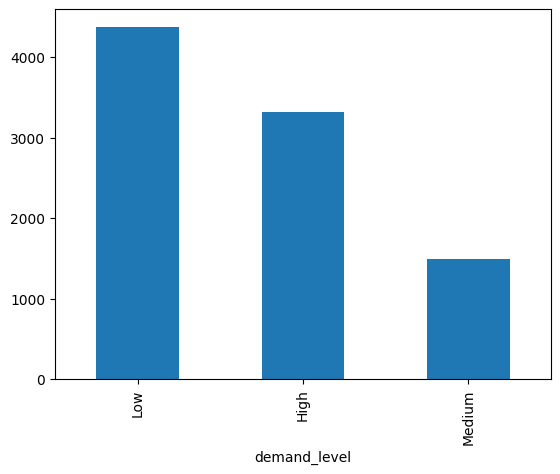

In [15]:
monthly_jobs['demand_level'].value_counts().plot(kind='bar')

## **Machine Learning Models**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
X = monthly_jobs.drop(['job_count', 'demand_level'], axis=1)
y = monthly_jobs['demand_level']

In [ ]:
X = pd.get_dummies(X, columns=['location', 'category'], drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC(),
    "kNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"{name}:")
    print(f"   Accuracy: {acc:.3%}")
    print(f"   F1-Score: {f1:.3%}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic:
   Accuracy: 63.419%
   F1-Score: 57.434%
Decision Tree:
   Accuracy: 67.120%
   F1-Score: 66.461%
Random Forest:
   Accuracy: 69.080%
   F1-Score: 65.753%
SVC:
   Accuracy: 47.686%
   F1-Score: 30.795%
kNN:
   Accuracy: 72.292%
   F1-Score: 70.526%
Gradient Boosting:
   Accuracy: 67.991%
   F1-Score: 62.647%


In [ ]:
models= {
    "Logistic": {
        'model': LogisticRegression(max_iter=1000),
        'params': {'C': [0.1, 1, 10]}
    },
    "Decision Tree": {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [None, 5, 10], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}
    },
    "Random Forest": {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {'n_estimators': [100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}
    },
    "SVC": {
        'model': SVC(max_iter=5000),
        'params': {'C': [0.1, 1, 10]}
    },
    "kNN": {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    },
    "Gradient Boosting": {
        'model': GradientBoostingClassifier(),
        'params': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]}
    }
}


for name, m in models.items():
    grid = GridSearchCV(m['model'], m['params'], cv=3, scoring='f1_weighted', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"{name}:")
    print(f"   Best Params: {grid.best_params_}")
    print(f"   Accuracy: {acc:.3%}")
    print(f"   F1-Score: {f1:.3%}")
    print("------")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic:
   Best Params: {'C': 10}
   Accuracy: 63.146%
   F1-Score: 56.893%
------
Decision Tree:
   Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
   Accuracy: 69.080%
   F1-Score: 67.626%
------
Random Forest:
   Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
   Accuracy: 69.679%
   F1-Score: 65.266%
------


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC:
   Best Params: {'C': 10}
   Accuracy: 47.686%
   F1-Score: 30.795%
------
kNN:
   Best Params: {'n_neighbors': 7, 'weights': 'distance'}
   Accuracy: 72.618%
   F1-Score: 71.103%
------
Gradient Boosting:
   Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
   Accuracy: 70.114%
   F1-Score: 65.981%
------


Confusion Matrix

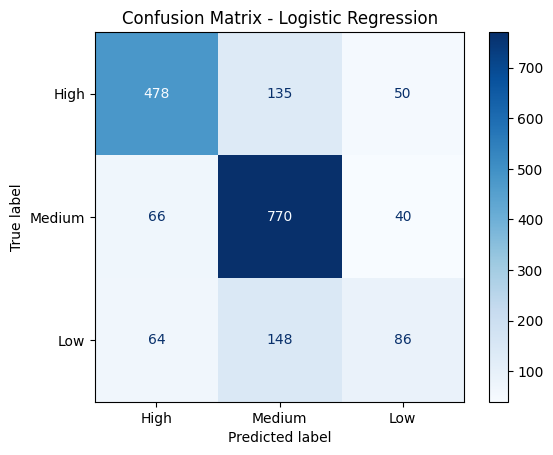

In [ ]:
best_model =  KNeighborsClassifier(n_neighbors=7,weights='distance')

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["High", "Medium", "Low"])

disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


Visualization

In [ ]:
import pandas as pd
import plotly.express as px

df['location'] = df['location'].str.strip()

location_demand = df.groupby('location').size().reset_index(name='job_count')

top_locations = location_demand.sort_values('job_count', ascending=False).head(10)

fig = px.bar(
    top_locations,
    x='job_count',
    y='location',
    orientation='h',
    color='job_count',
    color_continuous_scale='YlOrRd',
    title='Top 10 Job Hotspots in Malaysia'
)

fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()

In [ ]:
df['location'] = df['location'].str.strip().str.title()

location_totals = df.groupby('location').size().reset_index(name='total_jobs')

top_locations = location_totals.sort_values('total_jobs', ascending=False).head(5)['location']

filtered_df = df[df['location'].isin(top_locations)]

treemap_data = filtered_df.groupby(['location', 'category']).size().reset_index(name='job_count')

fig = px.treemap(
    treemap_data,
    path=['location', 'category'],
    values='job_count',
    color='job_count',
    color_continuous_scale='YlOrRd',
    title='Job Demand Hotspots by Location and Category'
)

fig.show()

In [ ]:
y_pred_all = best_model.predict(X)

monthly_jobs['predicted_class'] = y_pred_all

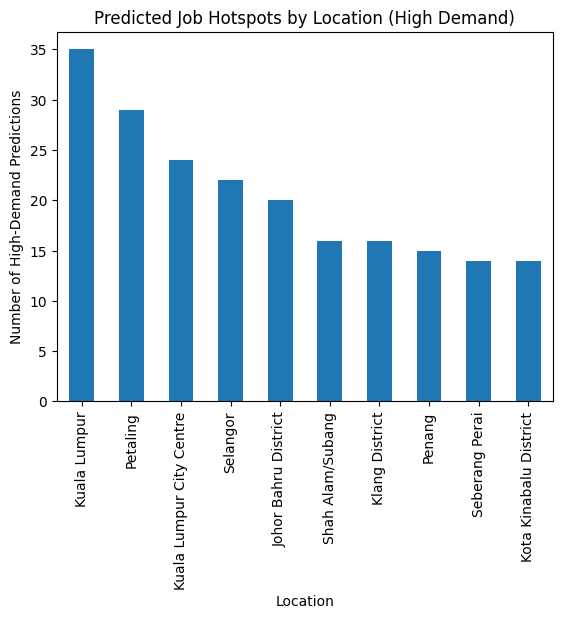

In [ ]:
monthly_jobs_test = X_test.copy()
monthly_jobs_test['actual_demand'] = y_test
monthly_jobs_test['predicted_demand'] = best_model.predict(X_test)

hotspots = monthly_jobs_test[
    monthly_jobs_test['predicted_demand'] == 'High'
]

hotspot_location = (
    hotspots
    .filter(like='location_')
    .idxmax(axis=1)
    .str.replace('location_', '')
)

hotspot_counts = hotspot_location.value_counts().head(10)

hotspot_counts.plot(kind='bar')
plt.title("Predicted Job Hotspots by Location (High Demand)")
plt.xlabel("Location")
plt.ylabel("Number of High-Demand Predictions")
plt.show()

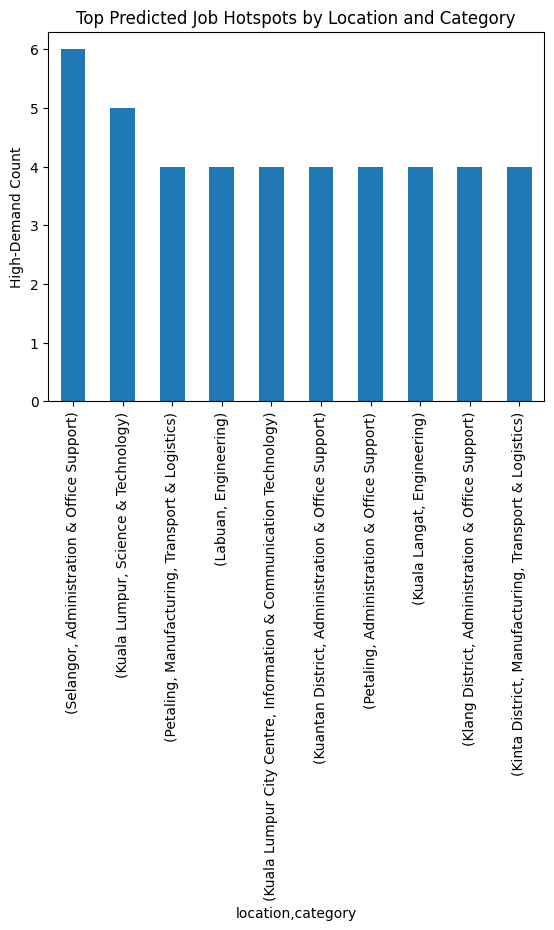

In [ ]:
hotspot_data = hotspots.copy()

hotspot_data['location'] = (
    hotspot_data.filter(like='location_')
    .idxmax(axis=1)
    .str.replace('location_', '')
)

hotspot_data['category'] = (
    hotspot_data.filter(like='category_')
    .idxmax(axis=1)
    .str.replace('category_', '')
)

hotspot_summary = (
    hotspot_data
    .groupby(['location', 'category'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(10)
)

hotspot_summary.set_index(['location', 'category'])['count'].plot(kind='bar')
plt.title("Top Predicted Job Hotspots by Location and Category")
plt.ylabel("High-Demand Count")
plt.show()

